# Controlled Small Molecule Generation for Drug Discovery using the MolMIM NIM with Custom Oracles

```{note}
This notebook assumes that you have the MolMIM NIM available at the following address: `http://localhost:$CONTAINER_PORT`. If your container is available at different address, you will need to modify the URL below. If you haven't already, Please follow the steps in container_setup.ipynb
```

In the field of drug discovery, identifying novel and effective compounds is a crucial step in the development of new medicines. Chemical space, the vast expanse of all possible chemical compounds, is a complex landscape that can be difficult to navigate. Molecular generative AI models, such as MolMIM, can be used to sample this space and identify promising compounds.

## CMA-ES: A Global Optimization Algorithm

CMA-ES (Covariance Matrix Adaptation Evolution Strategy) is a global optimization algorithm that is well-suited for optimizing complex objective functions such as the QED score. It uses a population of candidate solutions to search for the optimal solution, and adapts the covariance matrix of the search distribution to improve the search process.

## Objectives

In this notebook, we will use MolMIM to perform guided optimization on an imatinib seed using CMA-ES and a custom oracle scoring function to optimize for desired properties.

## Setup

We'll first install and import required dependencies, including the RDKit QED and TanimotoSimilarity functions that we'll use to construct our oracle scoring function.

In [ ]:
import hashlib
import json
import math
import os
import pickle
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import cma
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import clear_output, display
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import Descriptors, Draw, FilterCatalog
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem.QED import qed
from rdkit.DataStructs import TanimotoSimilarity
from config import CONTAINER_PORT


RDLogger.DisableLog('rdApp.*')

### Composite Scoring Aligned with `evaluate_submission.py`

To mirror the hackathon evaluation pipeline, we score every molecule with the same components used in `scoring/evaluate_submission.py`: drug-likeness (QED), synthetic accessibility, PAINS liabilities, ChEMBL novelty, and mock CDK4 vs CDK11 affinity estimates that reward high on-target potency while discouraging CDK11 binding.


In [ ]:
COMPOSITE_WEIGHTS: Dict[str, float] = {
    "binding_affinity": 0.25,
    "selectivity": 0.15,
    "cdk11_avoidance": 0.20,
    "qed": 0.15,
    "sa": 0.10,
    "pains": 0.10,
    "novelty": 0.05,
}

WEIGHT_MAPPING: Dict[str, str] = {
    "binding_affinity": "on_target_pic50_norm",
    "selectivity": "selectivity_ratio_norm",
    "cdk11_avoidance": "cdk11_avoidance_norm",
    "qed": "qed_score_norm",
    "sa": "sa_score_normalized_norm",
    "pains": "pains_score_norm",
    "novelty": "novelty_score_norm",
}

NOVELTY_CUTOFF_DEFAULT = 0.85
SELECTIVITY_CAP = 50.0
PIC50_TARGET_RANGE = (5.0, 9.0)
CONFIDENCE_THRESHOLD = 0.2


def _resolve_chembl_cache_path() -> Path:
    env_path = os.environ.get("CHEMBL_FINGERPRINT_CACHE")
    if env_path:
        return Path(env_path).expanduser()
    fallback = (
        Path.cwd()
        / ".."
        / ".."
        / "scoring"
        / "chembl_data"
        / "chembl_fingerprints.pkl"
    ).resolve(strict=False)
    return fallback


CHEMBL_FP_PATH = _resolve_chembl_cache_path()


def load_reference_fingerprints(path: Path) -> Dict[str, Any]:
    if path.exists():
        with open(path, "rb") as handle:
            ref = pickle.load(handle)
        print(f"Loaded {len(ref):,} ChEMBL reference fingerprints from {path}")
        return ref
    print(
        "Warning: ChEMBL fingerprint cache not found at",
        path,
        "\n         Novelty scores default to 1.0 (fully novel).",
    )
    return {}


REFERENCE_FPS = load_reference_fingerprints(CHEMBL_FP_PATH)

PAINS_PARAMS = FilterCatalog.FilterCatalogParams()
PAINS_PARAMS.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS_A)
PAINS_PARAMS.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS_B)
PAINS_PARAMS.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS_C)
PAINS_CATALOG = FilterCatalog.FilterCatalog(PAINS_PARAMS)


def calculate_sa_score(mol: Chem.Mol) -> Dict[str, float]:
    score = 0.0
    score += min(mol.GetNumHeavyAtoms() / 50, 1) * 2
    score += min(len(Chem.GetSymmSSSR(mol)) / 6, 1) * 2
    score += min(Descriptors.BertzCT(mol) / 1000, 1) * 3
    score += min(Descriptors.NumHeteroatoms(mol) / 10, 1) * 1
    score += min(Descriptors.NumRotatableBonds(mol) / 10, 1) * 2
    normalized = 1 - (score / 10)
    return {
        "sa_score": float(score),
        "sa_score_normalized": float(np.clip(normalized, 0, 1)),
    }


def calculate_cdk11_avoidance(ic50_nm: Optional[float]) -> float:
    if ic50_nm is None or np.isnan(ic50_nm):
        return float("nan")
    if ic50_nm >= 10000:
        return 1.0
    if ic50_nm >= 1000:
        return 0.5 + 0.5 * (ic50_nm - 1000) / 9000
    return 0.5 * ic50_nm / 1000


def evaluate_pains(mol: Optional[Chem.Mol]) -> Dict[str, Any]:
    if mol is None:
        return {"is_pains": True, "pains_alerts": [], "pains_score": 0.0}
    if not PAINS_CATALOG.HasMatch(mol):
        return {"is_pains": False, "pains_alerts": [], "pains_score": 1.0}
    alerts = [entry.GetDescription() for entry in PAINS_CATALOG.GetMatches(mol)]
    return {"is_pains": True, "pains_alerts": alerts, "pains_score": 0.0}


def novelty_metrics(mol: Optional[Chem.Mol], cutoff: float = NOVELTY_CUTOFF_DEFAULT) -> Dict[str, Any]:
    if mol is None:
        return {
            "max_chembl_similarity": float("nan"),
            "is_novel": False,
            "novelty_score": 0.0,
        }
    if not REFERENCE_FPS:
        return {"max_chembl_similarity": 0.0, "is_novel": True, "novelty_score": 1.0}
    query_fp = GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    max_sim = 0.0
    for ref_fp in REFERENCE_FPS.values():
        sim = DataStructs.TanimotoSimilarity(query_fp, ref_fp)
        if sim > max_sim:
            max_sim = sim
            if max_sim >= cutoff:
                break
    is_novel = max_sim < cutoff
    novelty_score = 1.0 - min(max_sim, cutoff) / cutoff
    if not is_novel:
        novelty_score = 0.0
    return {
        "max_chembl_similarity": float(max_sim),
        "is_novel": bool(is_novel),
        "novelty_score": float(np.clip(novelty_score, 0, 1)),
    }


def _seed_from_smiles(smiles: str, target: str) -> int:
    digest = hashlib.sha256(f"{smiles}|{target}".encode("utf-8")).hexdigest()
    return int(digest[:16], 16) % (2**32)


def mock_affinity_predictions(smiles: str) -> Dict[str, Dict[str, float]]:
    affinities: Dict[str, Dict[str, float]] = {}
    for target in ("CDK4", "CDK11"):
        rng = np.random.default_rng(_seed_from_smiles(smiles, target))
        mean = math.log(50 if target == "CDK4" else 5000)
        sigma = 0.6
        ic50_nm = float(rng.lognormal(mean=mean, sigma=sigma))
        pic50 = -math.log10(ic50_nm * 1e-9)
        confidence = float(rng.uniform(0.6, 0.95))
        affinities[target] = {
            "ic50_nm": ic50_nm,
            "pic50": pic50,
            "confidence": confidence,
            "prediction_accepted": confidence >= CONFIDENCE_THRESHOLD,
        }
    return affinities


def compute_binding_features(smiles: str) -> Dict[str, Any]:
    affinities = mock_affinity_predictions(smiles)
    on_target_pic50 = affinities["CDK4"]["pic50"]
    on_target_ic50 = affinities["CDK4"]["ic50_nm"]
    cdk11_ic50 = affinities["CDK11"]["ic50_nm"]
    selectivity_ratio = (
        float(cdk11_ic50 / on_target_ic50)
        if on_target_ic50 and on_target_ic50 > 0
        else float("nan")
    )
    cdk11_avoidance = calculate_cdk11_avoidance(cdk11_ic50)
    return {
        "affinities": affinities,
        "on_target_pic50": float(on_target_pic50),
        "on_target_ic50_nm": float(on_target_ic50),
        "selectivity_ratio": (
            float(selectivity_ratio) if not np.isnan(selectivity_ratio) else float("nan")
        ),
        "cdk11_avoidance": float(cdk11_avoidance),
    }


def normalize_metrics(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    df = df.copy()

    if "on_target_pic50" in df.columns:
        series = df["on_target_pic50"].replace([np.inf, -np.inf], np.nan)
        if series.notna().any():
            series = series.fillna(series.median())
            max_val = series.max()
            min_val = series.min()
            if max_val > min_val:
                normalized = (series - min_val) / (max_val - min_val)
            else:
                min_target, max_target = PIC50_TARGET_RANGE
                normalized = (series - min_target) / (max_target - min_target)
        else:
            normalized = pd.Series(0.5, index=df.index)
        df["on_target_pic50_norm"] = normalized.clip(0.0, 1.0).fillna(0.5)
    else:
        df["on_target_pic50_norm"] = 0.0

    if "selectivity_ratio" in df.columns:
        series = df["selectivity_ratio"].replace([np.inf, -np.inf], np.nan)
        if series.notna().any():
            series = series.fillna(series.median())
            normalized = (series / SELECTIVITY_CAP).clip(0.0, 1.0)
        else:
            normalized = pd.Series(0.0, index=df.index)
        df["selectivity_ratio_norm"] = normalized.fillna(0.0)
    else:
        df["selectivity_ratio_norm"] = 0.0

    if "cdk11_avoidance" in df.columns:
        series = df["cdk11_avoidance"]
        if series.notna().any():
            series = series.fillna(series.median())
            normalized = series.clip(0.0, 1.0)
        else:
            normalized = pd.Series(0.0, index=df.index)
        df["cdk11_avoidance_norm"] = normalized.fillna(0.0)
    else:
        df["cdk11_avoidance_norm"] = 0.0

    if "qed_score" in df.columns:
        series = df["qed_score"].fillna(df["qed_score"].median())
        df["qed_score_norm"] = series.clip(0.0, 1.0)
    else:
        df["qed_score_norm"] = 0.0

    if "sa_score_normalized" in df.columns:
        series = df["sa_score_normalized"].fillna(df["sa_score_normalized"].median())
        df["sa_score_normalized_norm"] = series.clip(0.0, 1.0)
    else:
        df["sa_score_normalized_norm"] = 0.0

    if "pains_score" in df.columns:
        df["pains_score_norm"] = df["pains_score"].fillna(0.0).clip(0.0, 1.0)
    else:
        df["pains_score_norm"] = 0.0

    if "novelty_score" in df.columns:
        df["novelty_score_norm"] = df["novelty_score"].fillna(0.0).clip(0.0, 1.0)
    else:
        df["novelty_score_norm"] = 0.0

    return df


def add_composite_scores(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    df = df.copy()
    composite = pd.Series(0.0, index=df.index, dtype=float)
    for weight_key, col_name in WEIGHT_MAPPING.items():
        if col_name in df.columns:
            values = df[col_name].fillna(0.0)
        else:
            values = pd.Series(0.0, index=df.index, dtype=float)
        contributions = COMPOSITE_WEIGHTS.get(weight_key, 0.0) * values
        df[f"{weight_key}_contribution"] = contributions
        composite = composite + contributions
    df["composite_score"] = composite
    return df


def score_molecule(
    smiles: str,
    reference_smiles: Optional[str] = None,
    novelty_cutoff: float = NOVELTY_CUTOFF_DEFAULT,
) -> Optional[Dict[str, Any]]:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    metrics: Dict[str, Any] = {
        "smiles": smiles,
        "canonical_smiles": Chem.MolToSmiles(mol, canonical=True),
    }

    metrics["tanimoto_to_seed"] = (
        tanimoto_similarity(smiles, reference_smiles)
        if reference_smiles is not None
        else float("nan")
    )

    metrics.update(calculate_sa_score(mol))
    pains_payload = evaluate_pains(mol)
    metrics.update(pains_payload)
    metrics.update(novelty_metrics(mol, cutoff=novelty_cutoff))
    metrics["qed_score"] = float(qed(mol))

    binding_payload = compute_binding_features(smiles)
    metrics.update(
        {
            "on_target_pic50": binding_payload["on_target_pic50"],
            "on_target_ic50_nm": binding_payload["on_target_ic50_nm"],
            "selectivity_ratio": binding_payload["selectivity_ratio"],
            "cdk11_avoidance": binding_payload["cdk11_avoidance"],
        }
    )
    metrics["affinities"] = binding_payload["affinities"]

    for target, values in binding_payload["affinities"].items():
        metrics[f"{target}_ic50_nm"] = values["ic50_nm"]
        metrics[f"{target}_pic50"] = values["pic50"]
        metrics[f"{target}_confidence"] = values["confidence"]
        metrics[f"{target}_prediction_accepted"] = values["prediction_accepted"]

    return metrics


def score_smiles_batch(
    smiles_list: List[str],
    reference_smiles: Optional[str] = None,
    novelty_cutoff: float = NOVELTY_CUTOFF_DEFAULT,
    sort_results: bool = True,
) -> pd.DataFrame:
    records = [
        score_molecule(smile, reference_smiles=reference_smiles, novelty_cutoff=novelty_cutoff)
        for smile in smiles_list
    ]
    valid_records = [record for record in records if record is not None]
    if not valid_records:
        return pd.DataFrame()
    df = pd.DataFrame(valid_records)
    df = df[df["is_pains"] != True].copy()
    if df.empty:
        return df
    df = df.reset_index(drop=True)
    df = normalize_metrics(df)
    df = add_composite_scores(df)
    if sort_results:
        df = df.sort_values("composite_score", ascending=False).reset_index(drop=True)
    return df


def evaluate_population(
    smiles_list: List[str],
    reference_smiles: Optional[str] = None,
    novelty_cutoff: float = NOVELTY_CUTOFF_DEFAULT,
) -> Tuple[pd.DataFrame, np.ndarray]:
    df = score_smiles_batch(
        smiles_list,
        reference_smiles=reference_smiles,
        novelty_cutoff=novelty_cutoff,
        sort_results=False,
    )
    if df.empty:
        return df, np.array([])
    losses = -df["composite_score"].to_numpy(dtype=float)
    return df, losses



### Define the NIM host
To get started, we'll define our NIM host and the NIM endpoints we'll use in the following cells.

 - `/sampling` - Perform random sampling around a seed SMILES to define a starting population
 - `/hidden` - Generate the hidden state encoding for a set of input SMILES
 - `/decode` - Decode hidden state encodings to return a set of SMILES

In [ ]:
nim_host="localhost"
port="8005"
sampling_url=f"http://{nim_host}:{CONTAINER_PORT}/sampling"
hidden_url=f"http://{nim_host}:{CONTAINER_PORT}/hidden"
decode_url=f"http://{nim_host}:{CONTAINER_PORT}/decode"

Let's run a health check on our NIM:

In [ ]:
!curl {nim_host}:{CONTAINER_PORT}/v1/health/ready

## Guided Molecular Generation with CMA-ES

In contrast to the random sampling of the latent space described above, we can use a black box optimizer, called CMA-ES, to perform guided optimization of a molecule's properties through sampling of the latent space. In the blocks below, we'll first generate and score a population of candidate molecules using random sampling, and then use CMA-ES to optimize the full composite scoring function aligned with the hackathon evaluation (potency, selectivity, CDK11 avoidance, QED, SA, PAINS, novelty).


The following code block defines a function called `tanimoto_similarity` that calculates the Tanimoto similarity between two molecules. The function takes two parameters: `smiles`, the SMILES string of the molecule to be compared, and `reference`, the SMILES string of the reference molecule. The function first gets the fingerprint parameters, then creates the fingerprint for the reference molecule. It then validates the input molecule by converting its SMILES string to a molecule object and checks if the object is None. If the object is None, it returns 0. Otherwise, it creates the fingerprint for the input molecule and calculates the Tanimoto similarity between the two fingerprints. The function returns the calculated Tanimoto similarity.

This function will be used along with the RDKit QED function to score both the randomly sampled population and to construct the oracle scoring function used with CMA-ES guided optimization.

In [ ]:
def tanimoto_similarity(smiles, reference: str):
    # Get fingerprint params
    fingerprint_radius_param = 2
    fingerprint_nbits = 2048

    # Handle the reference molecule
    reference_mol = Chem.MolFromSmiles(reference)
    reference_fingerprint = GetMorganFingerprintAsBitVect(
        reference_mol, radius=fingerprint_radius_param, nBits=fingerprint_nbits
    )

    # Validate the other molecule
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 0

    fingerprint = GetMorganFingerprintAsBitVect(mol, radius=fingerprint_radius_param, nBits=fingerprint_nbits)

    # Calculate and return the Tanimoto similarity
    return TanimotoSimilarity(fingerprint, reference_fingerprint)

### First an example using random sampling around the imatinib seed

In the following block, we define the imatinib seed and use the `/sampling` endpoint to randomly sample latent space to generate a candidate population. We then score those molecules with the full composite criteria (QED, synthetic accessibility, PAINS, novelty, and mock CDK4 vs CDK11 affinity) and review the top-ranked candidates.



In [ ]:
# Define a starting array of seed SMIs

imatinib = 'CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5'

mol = Chem.MolFromSmiles(imatinib)
imatinib_qed = qed(mol)

starting_smiles = [imatinib] * 5

generated_smiles: List[str] = []

for smi in starting_smiles:
    data = {
        'sequences': [smi],
        'beam_size': 3,
        'num_molecules': 10,
        'scaled_radius': 1.0,
    }

    headers = {'Content-Type': 'application/json'}
    response = requests.post(sampling_url, headers=headers, json=data)
    response_json = json.loads(response.text)
    generated_molecules = response_json['generated'][0]
    valid_smiles = [m for m in generated_molecules if Chem.MolFromSmiles(m) is not None]
    generated_smiles.extend(valid_smiles)

population_df, _ = evaluate_population(generated_smiles, reference_smiles=imatinib)
if population_df.empty:
    raise RuntimeError("No valid, non-PAINS molecules generated from random sampling.")

population_df = population_df.sort_values('composite_score', ascending=False).reset_index(drop=True)

sampling_summary = {
    'valid_smiles': len(population_df),
    'mean_composite': population_df['composite_score'].mean(),
    'median_composite': population_df['composite_score'].median(),
    'mean_qed': population_df['qed_score'].mean(),
    'mean_sa_norm': population_df['sa_score_normalized'].mean(),
    'mean_novelty': population_df['novelty_score'].mean(),
    'mean_selectivity': population_df['selectivity_ratio'].replace([np.inf, -np.inf], np.nan).mean(),
    'mean_tanimoto': population_df['tanimoto_to_seed'].mean(),
}

summary_df = pd.DataFrame.from_dict(sampling_summary, orient='index', columns=['value'])
print("Random sampling summary (non-PAINS only):")
display(summary_df)

key_columns = [
    'canonical_smiles',
    'composite_score',
    'qed_score',
    'sa_score_normalized',
    'novelty_score',
    'on_target_pic50',
    'selectivity_ratio',
    'cdk11_avoidance',
    'tanimoto_to_seed',
]
print("Top 5 molecules by composite score:")
display(population_df[key_columns].head(5))


### Composite Scoring Oracle

To stay consistent with `evaluate_submission.py`, our CMA-ES loop optimizes the composite score built from the weighted contributions of binding affinity, selectivity, CDK11 avoidance, QED, synthetic accessibility, PAINS penalty, and novelty. The optimizer still performs minimization under the hood, so we will pass the negative composite scores back to CMA-ES.

In [ ]:
def composite_objective(smiles_list: List[str]) -> Tuple[pd.DataFrame, np.ndarray]:
    return evaluate_population(smiles_list, reference_smiles=imatinib)

initial_losses = -population_df['composite_score'].to_numpy()

We can now visualize how the initial population distributes in QED–similarity space, coloring each point by its composite score.

In [ ]:
%matplotlib inline
plt.ion()
fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(
    population_df['qed_score'],
    population_df['tanimoto_to_seed'],
    c=population_df['composite_score'],
    cmap='viridis',
    edgecolor='0.8',
    linewidths=0.7,
)
ax.axvline(imatinib_qed, linestyle=':', color='k', label='Imatinib QED')
ax.set_xlabel('QED')
ax.set_ylabel('Similarity to seed')
ax.set_title('Random sampling composite scores')
ax.legend(loc='lower right')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Composite score')
plt.draw()

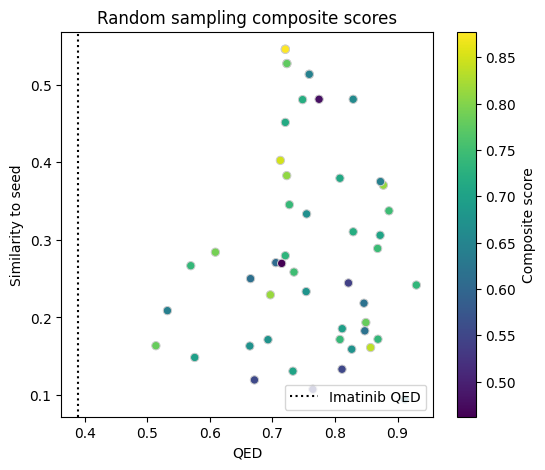



## Controlled Generation with CMA-ES and the custom oracle

### Generate hidden state encoding for the imatinib seed to initialize CMA-ES

To start the CMA-ES optimization process, we first seed the optimizer with the hidden state encoding for our imatinib seed molecule using the `/hidden` endpoint.

In [ ]:
# First calculate a hidden state representation of our seed, imatinib.
headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json'
}
data = {
    "sequences": [imatinib],
}

# Get the response from the server
response = requests.post(hidden_url, headers=headers, json=data)
imatinib_hidden = np.squeeze(np.array(response.json()["hiddens"]))

# We can use this seed hidden state as a starting point for our CMA-ES optimizer
popsize = len(population_df)
sigma = 1.0

# Initialize with zeros or the hidden state encoding for imatinib
#optimizer = cma.CMAEvolutionStrategy(np.zeros(imatinib_hidden.size, dtype=np.float32), sigma, {'popsize': popsize})
optimizer = cma.CMAEvolutionStrategy(imatinib_hidden, sigma, {'popsize': popsize})

Now that we've initialized the CMA-ES optimizer, we can generate and decode an initial set of trial encodings using the `/decode` endpoint.

In [ ]:
# Generate and decode a set of initial trial encodings with CMA-ES

trial_encodings = optimizer.ask(popsize)

headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json'
}
hiddens_array = np.expand_dims(np.array(trial_encodings), axis=1)
hiddens_json = {
    "hiddens": hiddens_array.tolist(),
    "mask": [[True] for _ in range(hiddens_array.shape[0])]
}

response = requests.post(decode_url, headers=headers, json=hiddens_json)
molecules = list(dict.fromkeys(response.json()['generated']))
valid_smiles = [m for m in molecules if Chem.MolFromSmiles(m) is not None]

trial_df_raw, trial_losses = composite_objective(valid_smiles)
if trial_df_raw.empty:
    raise RuntimeError("No valid, non-PAINS molecules decoded from initial CMA-ES trial.")

trial_df = trial_df_raw.sort_values('composite_score', ascending=False).reset_index(drop=True)
popsize = len(trial_losses)
print(f"Initial CMA-ES population size (non-PAINS): {popsize}")

We can then inspect the decoded population, again using composite scores for ranking and visualization.

In [ ]:
%matplotlib inline

print(f"Current popsize = {popsize}")
print("Top decoded candidates:")
display(trial_df[key_columns].head(5))

plt.ion()
fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(
    trial_df['qed_score'],
    trial_df['tanimoto_to_seed'],
    c=trial_df['composite_score'],
    cmap='viridis',
    edgecolor='0.8',
    linewidths=0.7,
)
ax.axvline(imatinib_qed, linestyle=':', color='k', label='Imatinib QED')
ax.set_xlabel('QED')
ax.set_ylabel('Similarity to seed')
ax.set_title('Initial CMA-ES decoded population')
ax.legend(loc='lower right')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Composite score')
plt.draw()

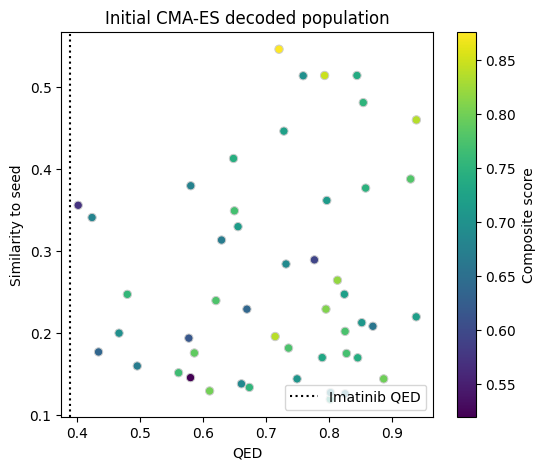

### Iterative optimization with CMA-ES and the composite oracle
Now that we have our starting population, we can iteratively optimize using the CMA-ES strategy:

1. Generate a new set of trial encodings
2. Decode and calculate the composite scores (affinity, selectivity, CDK11 avoidance, QED, SA, PAINS, novelty)
3. Regenerate hidden representations for the surviving, non-PAINS molecules
4. Update the CMA-ES optimizer with those hidden states and the negative composite scores

If an iteration collapses to the minimum population size or yields only filtered-out molecules, we end the loop to keep the optimizer stable.

In [ ]:
%matplotlib inline
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

scatter = ax1.scatter(
    trial_df['qed_score'],
    trial_df['tanimoto_to_seed'],
    c=trial_df['composite_score'],
    cmap='viridis',
    edgecolor='0.8',
    linewidths=0.7,
)
ax1.axvline(imatinib_qed, linestyle=':', color='k')
ax1.set_xlabel('QED')
ax1.set_ylabel('Similarity to seed')
cbar = fig.colorbar(scatter, ax=ax1)
cbar.set_label('Composite score')

med_qeds = [trial_df['qed_score'].median()]
med_sims = [trial_df['tanimoto_to_seed'].median()]
med_composites = [trial_df['composite_score'].median()]

minpopsize = max(2, int(popsize / 2))
n_steps = 50

for i in range(n_steps):
    trial_encodings = optimizer.ask(popsize)
    print(f"Size trial encodings = {len(trial_encodings)}")

    headers = {
        'accept': 'application/json',
        'Content-Type': 'application/json'
    }
    hiddens_array = np.expand_dims(np.array(trial_encodings), axis=1)
    hiddens_json = {
        "hiddens": hiddens_array.tolist(),
        "mask": [[True] for _ in range(hiddens_array.shape[0])]
    }

    response = requests.post(decode_url, headers=headers, json=hiddens_json)
    molecules = list(dict.fromkeys(response.json()['generated']))
    valid_smiles = [m for m in molecules if Chem.MolFromSmiles(m) is not None]
    if not valid_smiles:
        print("No valid SMILES generated; stopping optimization.")
        break

    iteration_df_raw, iteration_losses = composite_objective(valid_smiles)
    if iteration_df_raw.empty:
        print("All decoded molecules were filtered out (PAINS or invalid scoring). Skipping iteration.")
        continue

    filtered_smiles = iteration_df_raw['smiles'].tolist()
    data = {
        "sequences": filtered_smiles,
    }
    response = requests.post(hidden_url, headers=headers, json=data)
    hiddens_matrix = np.array(response.json()["hiddens"])
    hiddens_matrix = hiddens_matrix.reshape(len(filtered_smiles), -1)

    popsize = len(iteration_losses)
    print(f"Valid SMILES at iteration {i} = {popsize}")

    if popsize <= minpopsize:
        print(f"Stopping at minimum population size {popsize}\n")
        break

    optimizer.tell(hiddens_matrix, iteration_losses.tolist())

    iteration_df = iteration_df_raw.sort_values('composite_score', ascending=False).reset_index(drop=True)

    med_qeds.append(iteration_df['qed_score'].median())
    med_sims.append(iteration_df['tanimoto_to_seed'].median())
    med_composites.append(iteration_df['composite_score'].median())

    offsets = np.column_stack((iteration_df['qed_score'], iteration_df['tanimoto_to_seed']))
    scatter.set_offsets(offsets)
    scatter.set_array(iteration_df['composite_score'].to_numpy())
    scatter.set_clim(vmin=iteration_df['composite_score'].min(), vmax=iteration_df['composite_score'].max())
    cbar.update_normal(scatter)
    ax1.set_title(f'CMA-ES iteration {i + 1}')

    ax2.clear()
    med_range = range(len(med_qeds))
    ax2.plot(med_range, med_qeds, label='Median QED')
    ax2.plot(med_range, med_sims, label='Median similarity')
    ax2.plot(med_range, med_composites, label='Median composite')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Value')
    ax2.set_xlim(0, n_steps)
    ax2.set_ylim(0, 1)
    ax2.legend()

    clear_output(wait=True)
    display(fig)

plt.close(fig)

final_df = iteration_df if 'iteration_df' in locals() else trial_df


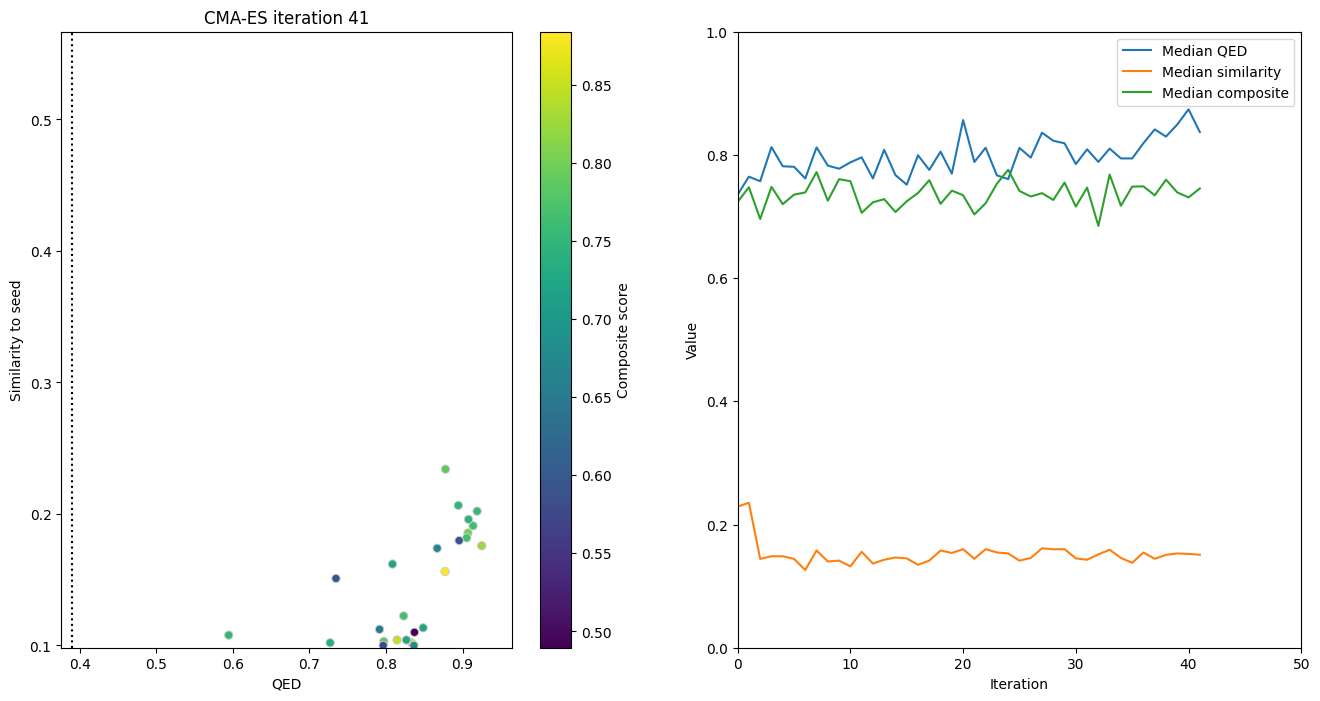

## Viewing the resulting optimized molecules.

In [ ]:
top_k = min(12, len(final_df))
final_df_sorted = final_df.sort_values('composite_score', ascending=False).head(top_k)
legend_entries = []
for _, row in final_df_sorted.iterrows():
    selectivity = row.selectivity_ratio
    selectivity_str = "NaN" if pd.isna(selectivity) else f"{selectivity:.1f}"
    legend_entries.append(
        f"Score={row.composite_score:.3f}\nQED={row.qed_score:.2f}\nSel={selectivity_str}"
    )
Draw.MolsToGridImage(
    [Chem.MolFromSmiles(smile, sanitize=False) for smile in final_df_sorted['canonical_smiles']],
    legends=legend_entries,
    molsPerRow=4,
    subImgSize=(300, 300)
)

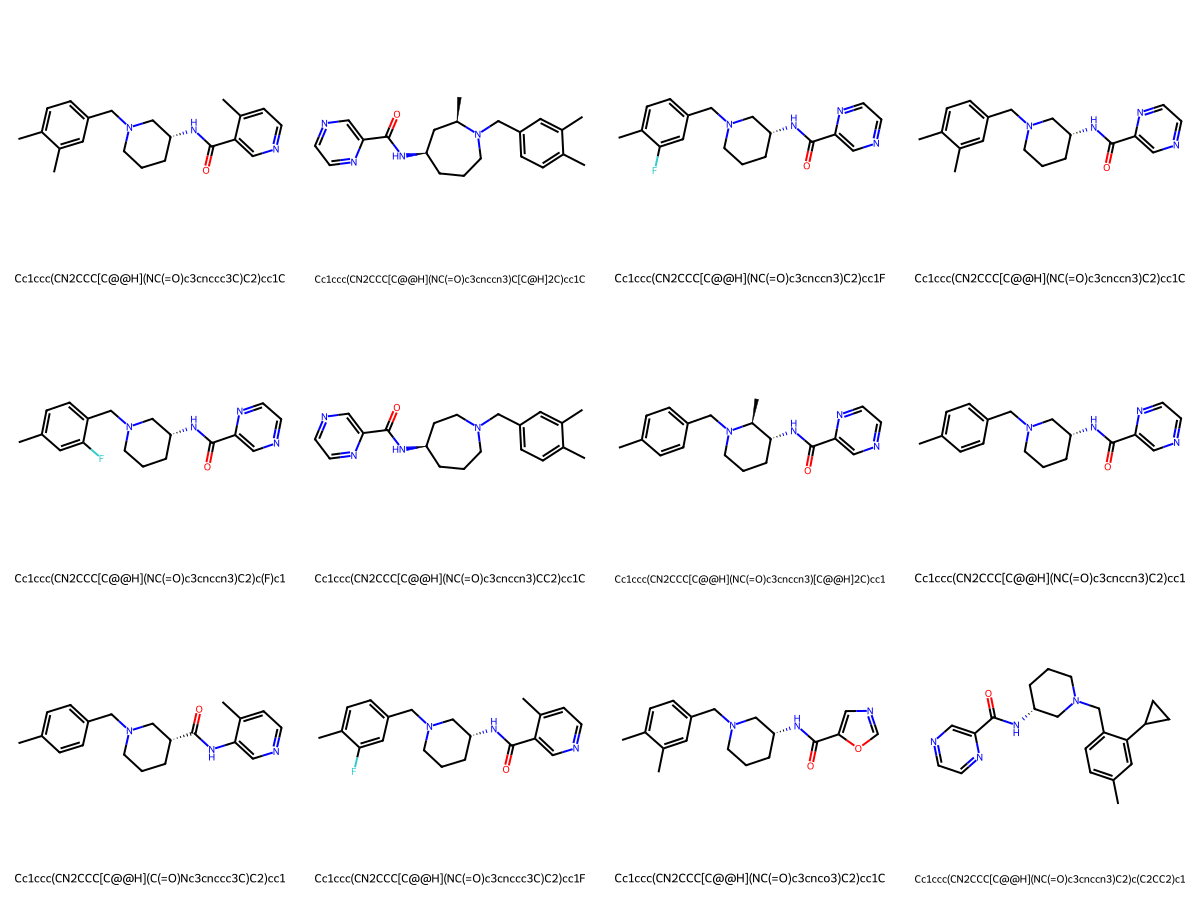

# Licensing

Copyright © 2025 OpenACC-Standard.org.  This material is released by OpenACC-Standard.org, in collaboration with NVIDIA Corporation, under the Creative Commons Attribution 4.0 International (CC BY 4.0). These materials may include references to hardware and software developed by other entities; all applicable licensing and copyrights apply.